In [ ]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

In [2]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [4]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [5]:
import numpy as np

In [6]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [7]:
# from sagemaker.tuner import HyperparameterTuner  ← requiere sagemaker instalado
# El nombre del mejor job ya está hardcodeado en la celda de carga del modelo
nombre_exportado = 'hpo-plaft-pn-masivo-260623-2030-038-a07095fc'
print(nombre_exportado)


hpo-plaft-pn-masivo-260623-2030-038-a07095fc


In [8]:
!pip install xgboost --prefer-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'
nombre_exportado = 'hpo-plaft-pn-masivo-260701-1603-042-a270185f'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix

In [10]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['cod_mes', 'key_value' ,'cuc_num']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_test[['key_value', 'cuc_num' ,'cod_mes', 'target']].head())

Se cargaron 35 variables desde S3
Primeras 10 variables: ['target', 'concentracion_dia_max', 'n_canales_distintos', 'monto_max_soles', 'monto_debitos_soles', 'ratio_debito_credito', 'fe_ratio_salidas_entradas', 'n_trx_otros', 'monto_transferencias_soles', 'imp_trx_abonosefect_12m']

Shapes cargados desde S3:
  Test  : (15286742, 35)

Listo! Todo cargado correctamente desde S3
df_test ahora tiene 38 columnas


,key_value,cuc_num,cod_mes,target
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,202508.0,0.0
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,202508.0,0.0
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,202508.0,0.0
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,202508.0,0.0
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,202508.0,0.0


In [11]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [12]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='0')]

In [13]:
df_test_1= df_test

In [14]:
# Guardar parquet en S3
#df_test_0426.to_parquet(
#    's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA_PILOTO/202604.parquet',
#    index=False
#)

In [15]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test_1.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [16]:
df_test_3['prob'] = model.predict(dtest)

In [17]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.896255
202510.0    0.850381
202511.0    0.846794
202602.0    0.963407
202604.0    0.866093
202605.0    0.871523
202606.0    0.865261
202607.0    0.636291
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_41408\29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [18]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.8495


In [19]:
#df_test_1 = df_test[df_test['cod_mes'].between(202508, 202604)].copy()

In [20]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
#df_test_2 = df_test_1.copy()
#df_test_3= df_test_2[(df_test_2.tipo_alerta_n2 =='AUTOMATICA')&(df_test_2.trx_riesgo_cliente !='A')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_1.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [21]:
predictions = model.predict(dtest)
y_test = df_test_1.target.to_frame()
y_test['prob'] = predictions
y_test_1=y_test['target'].values
y_score=y_test['prob'].values
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.0008900000000000001, 0.0044]",3057322,27,0.000009,0.200025,1.000000,3057322,2068
"(0.0044, 0.00911]",3057303,45,0.000015,0.400049,0.986944,6114625,2041
"(0.00911, 0.016]",3057293,55,0.000018,0.600073,0.965184,9171918,1996
"(0.016, 0.0334]",3057268,80,0.000026,0.800095,0.938588,12229186,1941
"(0.0334, 0.999]",3055488,1861,0.000609,1.000000,0.899903,15284674,1861


In [22]:

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# ================================================================
# SHAP Analysis – usa model.feature_names para evitar shape mismatch
# ================================================================

N_SAMPLE     = 5_000
RANDOM_STATE = 42

# Features exactas que el modelo espera
_model_features = model.feature_names
print(f"Modelo entrenado con {len(_model_features)} features")

# --- 0. Índices sin copiar el df ---
_mask_pos = (df_test_1['target'] == 1).to_numpy()
_mask_neg = (df_test_1['target'] == 0).to_numpy()
_all_idx  = np.arange(len(df_test_1))

_idx_pos = _all_idx[_mask_pos]
_idx_neg = _all_idx[_mask_neg]

n_pos = min(len(_idx_pos), max(50, int(N_SAMPLE * 0.10)))
n_neg = N_SAMPLE - n_pos

rng = np.random.default_rng(RANDOM_STATE)
_sampled_idx = np.concatenate([
    rng.choice(_idx_pos, size=n_pos, replace=False),
    rng.choice(_idx_neg, size=n_neg, replace=False),
])
rng.shuffle(_sampled_idx)

# --- 1. Construir X_shap con EXACTAMENTE las features del modelo ---
X_shap = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx] for col in _model_features}
).reset_index(drop=True)

d_shap = xgb.DMatrix(X_shap, enable_categorical=True)
print(f"Muestra SHAP: {d_shap.num_row():,} filas x {d_shap.num_col()} variables")
print(f"  Positivos: {n_pos} | Negativos: {n_neg}")

# --- 2. SHAP values ---
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(d_shap)
shap_df     = pd.DataFrame(shap_values, columns=X_shap.columns)

# --- 3. Bar plot (top 20) ---
print("\n--- SHAP: Importancia absoluta (mean |SHAP|) ---")
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("SHAP – Importancia de variables (top 20)")
plt.tight_layout()
plt.show()

# --- 4. Beeswarm (top 20) ---
print("\n--- SHAP Beeswarm: dirección del efecto ---")
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Beeswarm – Dirección del efecto (top 20)")
plt.tight_layout()
plt.show()

# --- 5. Tabla resumen ---
resultados_shap = []
for col in X_shap.columns:
    mediana   = X_shap[col].median()
    mask_alto = X_shap[col] > mediana
    idx_col   = X_shap.columns.get_loc(col)

    shap_global = np.abs(shap_values[:, idx_col]).mean()
    shap_alto   = shap_df.loc[mask_alto,  col].mean()
    shap_bajo   = shap_df.loc[~mask_alto, col].mean()

    if shap_alto > 0.01:
        efecto = "🔴 Valor alto → AUMENTA riesgo"
    elif shap_bajo > 0.01:
        efecto = "🟠 Valor bajo → AUMENTA riesgo"
    else:
        efecto = "⚪ Efecto mixto / débil"

    resultados_shap.append({
        "variable":         col,
        "shap_importancia": shap_global,
        "shap_valor_alto":  shap_alto,
        "shap_valor_bajo":  shap_bajo,
        "efecto":           efecto,
    })

df_shap_resumen = (
    pd.DataFrame(resultados_shap)
    .sort_values("shap_importancia", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Tabla SHAP con dirección (top 20) ---")
display(
    df_shap_resumen.head(20)
    .style.format({
        "shap_importancia": "{:.4f}",
        "shap_valor_alto":  "{:.4f}",
        "shap_valor_bajo":  "{:.4f}",
    })
    .background_gradient(subset=["shap_valor_alto"], cmap="RdYlGn", vmin=-0.3, vmax=0.3)
)


ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

In [23]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [24]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

In [25]:

import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# ================================================================
# SHAP mes 202508 – features exactas del modelo
# ================================================================
N_SAMPLE     = 5_000
RANDOM_STATE = 42

_model_features = model.feature_names
print(f"Modelo entrenado con {len(_model_features)} features")

_all_idx = np.arange(len(df_test_1))
_mes_arr = df_test_1['cod_mes'].to_numpy()
_tgt_arr = df_test_1['target'].to_numpy()

# cod_mes puede ser float (202508.0) → comparar con float
_idx_pos = _all_idx[(_mes_arr == 202508) | (_mes_arr == 202508.0)]
_idx_neg_mes = _all_idx[(_mes_arr == 202508) | (_mes_arr == 202508.0)]
_idx_pos = _all_idx[((_mes_arr == 202508) | (_mes_arr == 202508.0)) & (_tgt_arr == 1)]
_idx_neg = _all_idx[((_mes_arr == 202508) | (_mes_arr == 202508.0)) & (_tgt_arr == 0)]

n_pos = min(len(_idx_pos), max(50, int(N_SAMPLE * 0.10)))
n_neg = min(len(_idx_neg), N_SAMPLE - n_pos)

rng = np.random.default_rng(RANDOM_STATE)
_sampled_idx = np.concatenate([
    rng.choice(_idx_pos, size=n_pos, replace=False),
    rng.choice(_idx_neg, size=n_neg, replace=False),
])
rng.shuffle(_sampled_idx)

print(f"Muestra 202508: {len(_sampled_idx):,} filas  (pos={n_pos}, neg={n_neg})")

# Features exactas del modelo
X_ref = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx] for col in _model_features}
).reset_index(drop=True)

dref = xgb.DMatrix(X_ref, enable_categorical=True)
print(f"DMatrix SHAP: {dref.num_row()} filas x {dref.num_col()} columnas")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dref)

# ================================================================
# Nombres gerenciales
# ================================================================
nombres_gerenciales_shap = {
    'imp_trx_abonosefect_12m':     'Monto total abonado en efectivo (12m)',
    'imp_trx_cargostot_1m':        'Monto total de cargos último mes',
    'cnt_trx_cargostot_12m':       'Número de cargos (12m)',
    'fe_zscore_cargos':            'Comportamiento atípico de cargos',
    'flg_vrcn_abonos_5m_1m':       'Incremento reciente de abonos',
    'imp_trx_cargosefe_12m':       'Monto anual cargos en efectivo',
    'concentracion_dia_max':       'Concentración máx. transacciones por día',
    'fe_velocidad_rotacion':       'Intensidad de uso de fondos',
    'mto_dif_abn_crgsefe_6m':      'Dif. montos abonos vs cargos efectivo (6m)',
    'ratio_debito_credito':        'Ratio débitos vs créditos',
    'cnt_dif_abn_crgsefe_6m':      'Dif. operaciones en efectivo (6m)',
    'rat_trx_mntabnsefetot_6m':    'Proporción abonos en efectivo (6m)',
    'monto_transferencias_soles':  'Monto transferencias en soles',
    'cnt_trx_abonostot_12m':       'Número de abonos totales (12m)',
    'td_avg_monto_1h':             'Monto promedio en 1 hora (TD)',
    'flg_activo':                  'Cliente con productos activos',
    'num_antiguedad':              'Antigüedad del cliente',
    'n_trx_mismo_cliente':         'Transferencias entre cuentas propias',
    'monto_debitos_soles':         'Monto total débitos en soles',
    'monto_total_dolares':         'Monto total en dólares',
    'fe_ratio_salidas_entradas':   'Ratio salidas vs entradas',
    'monto_max_soles':             'Monto máximo de transacción',
    'cnt_trx_abonosefect_12m':     'Número abonos en efectivo (12m)',
    'n_trx_pagos':                 'Número de pagos',
    'td_monto_total':              'Monto total tarjeta débito (mes)',
    'n_canales_distintos':         'Diversidad de canales',
    'monto_efectivo_soles':        'Monto total en efectivo',
    'fe_ratio_efectivo_vs_total':  'Proporción efectivo sobre total',
    'td_gap_promedio':             'Frecuencia de uso TD',
    'monto_promedio_dolares':      'Monto promedio en dólares',
    'n_trx_efectivo':              'Número de transacciones en efectivo',
    'n_trx_app':                   'Transacciones por APP',
    'tc_total_monto_mes':          'Monto total tarjeta crédito (mes)',
    'n_trx_otros':                 'Número de transacciones diversas',
}

print("\n--- SHAP: Importancia absoluta (top 20) ---")
shap.summary_plot(shap_values, X_ref, plot_type="bar", max_display=20, show=False)
plt.title("SHAP - Importancia de variables (top 20)")
plt.tight_layout()
plt.show()

print("\n--- SHAP Beeswarm: dirección del efecto ---")
shap.summary_plot(shap_values, X_ref, max_display=20, show=False)
plt.title("SHAP Beeswarm - Dirección del efecto (top 20)")
plt.tight_layout()
plt.show()

shap_df_full = pd.DataFrame(shap_values, columns=X_ref.columns)
resultados = []
for col in X_ref.columns:
    mediana   = X_ref[col].median()
    mask_alto = X_ref[col] > mediana
    idx_col   = X_ref.columns.get_loc(col)

    shap_global = np.abs(shap_values[:, idx_col]).mean()
    shap_alto   = shap_df_full.loc[mask_alto,  col].mean()
    shap_bajo   = shap_df_full.loc[~mask_alto, col].mean()

    efecto = ('🔴 Valor alto → AUMENTA riesgo' if shap_alto > 0.01
              else '🟠 Valor bajo → AUMENTA riesgo' if shap_bajo > 0.01
              else '⚪ Efecto mixto / débil')

    resultados.append({
        'variable_original':  col,
        'shap_importancia':   shap_global,
        'shap_si_valor_alto': shap_alto,
        'shap_si_valor_bajo': shap_bajo,
        'efecto_real':        efecto,
    })

df_shap = (
    pd.DataFrame(resultados)
    .sort_values('shap_importancia', ascending=False)
    .reset_index(drop=True)
)
df_shap['nombre_gerencial'] = (
    df_shap['variable_original'].map(nombres_gerenciales_shap)
    .fillna(df_shap['variable_original'])
)

print("\n--- Tabla SHAP con dirección correcta (top 20) ---")
display(
    df_shap[['nombre_gerencial', 'shap_importancia', 'shap_si_valor_alto', 'shap_si_valor_bajo', 'efecto_real']]
    .head(20)
    .style.format({
        'shap_importancia':   '{:.4f}',
        'shap_si_valor_alto': '{:.4f}',
        'shap_si_valor_bajo': '{:.4f}',
    })
    .background_gradient(subset=['shap_si_valor_alto'], cmap='RdYlGn', vmin=-0.3, vmax=0.3)
)


ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

In [26]:

import shap
import pandas as pd
import numpy as np
import xgboost as xgb

# ================================================================
# SHAP summary bar – mes 202508, features exactas del modelo
# ================================================================
N_SAMPLE     = 5_000
RANDOM_STATE = 42

_model_features = model.feature_names

_all_idx2 = np.arange(len(df_test_1))
_mes_arr2 = df_test_1['cod_mes'].to_numpy()
_tgt_arr2 = df_test_1['target'].to_numpy()

_idx_pos2 = _all_idx2[((_mes_arr2 == 202508) | (_mes_arr2 == 202508.0)) & (_tgt_arr2 == 1)]
_idx_neg2 = _all_idx2[((_mes_arr2 == 202508) | (_mes_arr2 == 202508.0)) & (_tgt_arr2 == 0)]
n_pos2 = min(len(_idx_pos2), max(50, int(N_SAMPLE * 0.10)))
n_neg2 = min(len(_idx_neg2), N_SAMPLE - n_pos2)

rng2 = np.random.default_rng(RANDOM_STATE)
_sampled_idx2 = np.concatenate([
    rng2.choice(_idx_pos2, size=n_pos2, replace=False),
    rng2.choice(_idx_neg2, size=n_neg2, replace=False),
])
rng2.shuffle(_sampled_idx2)

# Features exactas del modelo
X_ref2 = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx2] for col in _model_features}
).reset_index(drop=True)

print(f"X_ref2 shape: {X_ref2.shape}  (modelo espera {len(_model_features)} features)")

explainer2   = shap.TreeExplainer(model)
shap_values2 = explainer2.shap_values(xgb.DMatrix(X_ref2, enable_categorical=True))

# Exponer para la celda siguiente
shap_values  = shap_values2
X_ref_global = X_ref2

shap.summary_plot(shap_values2, X_ref2, plot_type="bar", max_display=20)


ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

In [27]:

# Usa las variables de la celda anterior (shap_values2 / X_ref_global)
variable_names = X_ref_global.columns

# Magnitud promedio de los SHAP values por variable
average_shap_values = np.abs(shap_values2).mean(axis=0)

# Lista de tuplas (variable, importancia_abs, shap_promedio)
variable_importance = [
    (name, imp, shap_mean)
    for name, imp, shap_mean in zip(
        variable_names,
        average_shap_values,
        shap_values2.mean(axis=0)
    )
]

# Orden descendente por importancia absoluta
variable_importance.sort(key=lambda x: x[1], reverse=True)
variables_mas_importantes = [(v[0], v[1], v[2]) for v in variable_importance]


NameError: name 'X_ref_global' is not defined

In [28]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


NameError: name 'variables_mas_importantes' is not defined

In [28]:
variables_mas_importantes

[('imp_trx_abonostot_3m', np.float32(0.4894852), np.float32(-0.25877407)),
 ('imp_trx_abonosefect_12m', np.float32(0.48612458), np.float32(-0.292833)),
 ('fe_zscore_cargos', np.float32(0.38739598), np.float32(-0.24814191)),
 ('imp_trx_cargosefe_12m', np.float32(0.36163622), np.float32(-0.24849917)),
 ('flg_vrcn_abonos_5m_1m', np.float32(0.28683785), np.float32(-0.124244004)),
 ('cnt_trx_cargostot_12m', np.float32(0.26885265), np.float32(-0.20388737)),
 ('cnt_dif_abn_crgsefe_6m', np.float32(0.18272398), np.float32(0.010413499)),
 ('concentracion_dia_max', np.float32(0.16876453), np.float32(-0.14512095)),
 ('fe_velocidad_rotacion', np.float32(0.15668726), np.float32(0.0029607208)),
 ('cnt_trx_abonostot_12m', np.float32(0.1554598), np.float32(-0.107617564)),
 ('ratio_debito_credito', np.float32(0.13684975), np.float32(-0.0127345035)),
 ('n_trx_mismo_cliente', np.float32(0.12650959), np.float32(-0.08548961)),
 ('num_antiguedad', np.float32(0.12520042), np.float32(-0.041862145)),
 ('monto_m

In [65]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.key_value as num_documento,
        a.cod_cli AS codunico,
        date_format(
            date_parse(CAST(a.p_codmes AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.p_codmes AS INTEGER) AS codmes

    

    FROM e_perm_aws.t_agg_alertas_plaft a
    WHERE a.p_codmes between '202508' AND '202607'
      AND a.desc_subsegmento  IN ('Masivo', 'Masivo Dependiente', 'Masivo Independiente')
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2,
        trx_riesgo_cliente,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2,trx_riesgo_cliente
)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    b.trx_riesgo_cliente,
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target_m
FROM pd a
LEFT JOIN target b
    ON a.codunico = b.codunico
 AND cast(a.codmes as varchar) = b.periodo_alerta
where  b.tipo_alerta_n2 is not null

;"""
df_dataset = athena_query(query, database='disc_comercial')
df_dataset.head()

CPU times: total: 1.42 s
Wall time: 10.9 s


,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,973DBB7DAFDE603875FF23028A72F15F2FDCD9AE73AA66...,0008988707,202511,202510,AUTOMATICA,M,0
1,973DBB7DAFDE603875FF23028A72F15F2FDCD9AE73AA66...,0008988707,202511,202510,MANUAL,M,0
2,A313B6DCAD413F5ED0D9A9EEA5BA29EF2D4F071E881385...,0010957459,202512,202511,AUTOMATICA,A,0
3,BAB1366782C5637B80968463E8F2F0E22A2742E88FFD5E...,0014360274,202606,202605,SEMI AUTOMATICA,B,0
4,AB87F178B5F6E9D18A2CA1B2A9C1BEBB7377B0A3470936...,0022148846,202606,202605,AUTOMATICA,<NA>,0


In [66]:
len(df_dataset)


7655

In [67]:
df_test_3.head()

,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,monto_total_dolares,monto_promedio_dolares,mto_dif_abn_crgsefe_6m,n_trx_pagos,tc_total_monto_mes,flg_activo,cod_mes,key_value,cuc_num,prob
0,0.0,0.666667,3.0,200.00,199.60,2.000000,0.997950,0.0,201.60,0.0,...,0.0,0.0,-3094.6,0.0,0.00,0.0,202508.0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.012573
1,0.0,0.666667,3.0,1642.58,1642.63,2.000000,1.026637,2.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,1.0,202508.0,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.010481
2,0.0,0.134615,4.0,1369.62,4117.00,1.476190,0.838078,18.0,2829.00,0.0,...,0.0,0.0,-4810.0,4.0,0.00,1.0,202508.0,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.007718
3,0.0,0.108108,2.0,321.00,987.70,1.740741,1.034230,9.0,1379.70,720.0,...,0.0,0.0,-50.0,1.0,0.00,0.0,202508.0,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.009579
4,0.0,0.187500,4.0,12709.00,14168.20,1.000000,1.014612,7.0,25415.15,16490.0,...,0.0,0.0,-5870.0,6.0,26327.79,1.0,202508.0,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.119544


In [68]:
#df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'codmes', 'num_documento', 'codunico']]

In [69]:
df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'cod_mes']]

In [70]:
df_final.head()

,key_value,cuc_num,prob,cod_mes
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.012573,202508.0
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.010481,202508.0
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.007718,202508.0
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.009579,202508.0
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.119544,202508.0


In [71]:
df_dataset.head()

,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,973DBB7DAFDE603875FF23028A72F15F2FDCD9AE73AA66...,0008988707,202511,202510,AUTOMATICA,M,0
1,973DBB7DAFDE603875FF23028A72F15F2FDCD9AE73AA66...,0008988707,202511,202510,MANUAL,M,0
2,A313B6DCAD413F5ED0D9A9EEA5BA29EF2D4F071E881385...,0010957459,202512,202511,AUTOMATICA,A,0
3,BAB1366782C5637B80968463E8F2F0E22A2742E88FFD5E...,0014360274,202606,202605,SEMI AUTOMATICA,B,0
4,AB87F178B5F6E9D18A2CA1B2A9C1BEBB7377B0A3470936...,0022148846,202606,202605,AUTOMATICA,<NA>,0


In [72]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="inner",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(4002, 11)


,key_value,cuc_num,prob,cod_mes,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,0.421150,202508,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,202509,202508,SEMI AUTOMATICA,A,1
1,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,0.977331,202508,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,202509,202508,AUTOMATICA,M,0
2,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,0.979677,202508,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,202509,202508,AUTOMATICA,A,1
3,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,0.759373,202508,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,202509,202508,MANUAL,B,1
4,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,0.781205,202508,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,202509,202508,AUTOMATICA,M,0


In [73]:
df_5 = df_merge[(df_merge.tipo_alerta_n2=='AUTOMATICA')]

In [74]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_5.groupby('cod_mes').apply(
    lambda x: gini(x['target_m'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508    0.355209
202510    0.638431
202511    0.369292
202602    0.370177
202604    0.242641
202605    0.339045
202606    0.570806
202607         NaN
dtype: float64


C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\b46637\AppData\Local\Temp\ipykernel_50048\2626577288.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_5.groupby('cod_mes').apply(


In [76]:
meses = [
    202508, 202510, 202511, 
    202601, 202602, 202603, 202604,202605,202606
]

tablas_quintiles = {}

# Normalizo mes
#df_merge["codmes_final"] = df_merge["codmes_final"].astype(str)

for mes in meses:
    mes_str = str(mes)

    test_data = df_5[
        df_5["cod_mes"] == mes_str
    ].copy()

    if test_data.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    if "target_m" not in test_data.columns:
        raise ValueError("No existe la columna target en df_4")

    if "prob" not in test_data.columns:
        raise ValueError("No existe la columna prob en df_4")

    tablas_quintiles[mes_str] = Tabla_Deciles(
        test_data["target_m"],
        test_data["prob"],
        n=5
    )

    print(f"✅ Mes {mes_str}: {len(test_data):,} registros")

✅ Mes 202508: 215 registros
✅ Mes 202510: 334 registros
✅ Mes 202511: 251 registros
⚠️ Sin datos para mes 202601
✅ Mes 202602: 415 registros
⚠️ Sin datos para mes 202603
✅ Mes 202604: 314 registros
✅ Mes 202605: 283 registros
✅ Mes 202606: 111 registros


In [77]:
tablas_quintiles['202508']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00258, 0.222]",41,2,0.046512,0.220430,1.000000,41,29
"(0.222, 0.631]",40,3,0.069767,0.435484,0.931034,81,27
"(0.631, 0.855]",37,6,0.139535,0.634409,0.827586,118,24
"(0.855, 0.954]",35,8,0.186047,0.822581,0.620690,153,18
"(0.954, 0.992]",33,10,0.232558,1.000000,0.344828,186,10


In [78]:
tablas_quintiles['202510']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00038999999999999994, 0.44]",67,0,0.000000,0.223333,1.000000,67,34
"(0.44, 0.763]",64,3,0.044776,0.436667,1.000000,131,34
"(0.763, 0.907]",61,5,0.075758,0.640000,0.911765,192,31
"(0.907, 0.961]",63,4,0.059701,0.850000,0.764706,255,26
"(0.961, 0.99]",45,22,0.328358,1.000000,0.647059,300,22


In [79]:
tablas_quintiles['202602']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0009599999999999999, 0.458]",75,8,0.096386,0.240385,1.000000,75,103
"(0.458, 0.785]",73,10,0.120482,0.474359,0.922330,148,95
"(0.785, 0.902]",62,21,0.253012,0.673077,0.825243,210,85
"(0.902, 0.961]",49,34,0.409639,0.830128,0.621359,259,64
"(0.961, 0.994]",53,30,0.361446,1.000000,0.291262,312,30


In [80]:
tablas_quintiles['202604']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00214, 0.444]",52,11,0.174603,0.235294,1.000000,52,93
"(0.444, 0.744]",47,16,0.253968,0.447964,0.881720,99,82
"(0.744, 0.904]",44,18,0.290323,0.647059,0.709677,143,66
"(0.904, 0.963]",40,23,0.365079,0.828054,0.516129,183,48
"(0.963, 0.994]",38,25,0.396825,1.000000,0.268817,221,25


In [81]:
tablas_quintiles['202605']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-3.0999999999999995e-05, 0.274]",55,2,0.035088,0.227273,1.000000,55,41
"(0.274, 0.718]",49,7,0.125000,0.429752,0.951220,104,39
"(0.718, 0.876]",51,6,0.105263,0.640496,0.780488,155,32
"(0.876, 0.959]",43,13,0.232143,0.818182,0.634146,198,26
"(0.959, 0.995]",44,13,0.228070,1.000000,0.317073,242,13


In [82]:
tablas_quintiles['202604']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00214, 0.444]",52,11,0.174603,0.235294,1.000000,52,93
"(0.444, 0.744]",47,16,0.253968,0.447964,0.881720,99,82
"(0.744, 0.904]",44,18,0.290323,0.647059,0.709677,143,66
"(0.904, 0.963]",40,23,0.365079,0.828054,0.516129,183,48
"(0.963, 0.994]",38,25,0.396825,1.000000,0.268817,221,25


In [83]:
tablas_quintiles['202605']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-3.0999999999999995e-05, 0.274]",55,2,0.035088,0.227273,1.000000,55,41
"(0.274, 0.718]",49,7,0.125000,0.429752,0.951220,104,39
"(0.718, 0.876]",51,6,0.105263,0.640496,0.780488,155,32
"(0.876, 0.959]",43,13,0.232143,0.818182,0.634146,198,26
"(0.959, 0.995]",44,13,0.228070,1.000000,0.317073,242,13


In [84]:
df_quintiles = pd.concat(
    [
        tabla.assign(mes=mes)
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles.head())

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes
0,41,2,0.046512,0.220430,1.000000,41,29,202508
1,40,3,0.069767,0.435484,0.931034,81,27,202508
2,37,6,0.139535,0.634409,0.827586,118,24,202508
3,35,8,0.186047,0.822581,0.620690,153,18,202508
4,33,10,0.232558,1.000000,0.344828,186,10,202508


In [85]:
df_quintiles = pd.concat(
    [
        tabla.reset_index(drop=True).assign(
            mes=str(mes),
            Quintil=range(1, len(tabla) + 1)
        )
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles)

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes,Quintil
0,41,2,0.046512,0.220430,1.000000,41,29,202508,1
1,40,3,0.069767,0.435484,0.931034,81,27,202508,2
2,37,6,0.139535,0.634409,0.827586,118,24,202508,3
3,35,8,0.186047,0.822581,0.620690,153,18,202508,4
4,33,10,0.232558,1.000000,0.344828,186,10,202508,5
5,67,0,0.000000,0.223333,1.000000,67,34,202510,1
6,64,3,0.044776,0.436667,1.000000,131,34,202510,2
7,61,5,0.075758,0.640000,0.911765,192,31,202510,3
8,63,4,0.059701,0.850000,0.764706,255,26,202510,4
9,45,22,0.328358,1.000000,0.647059,300,22,202510,5


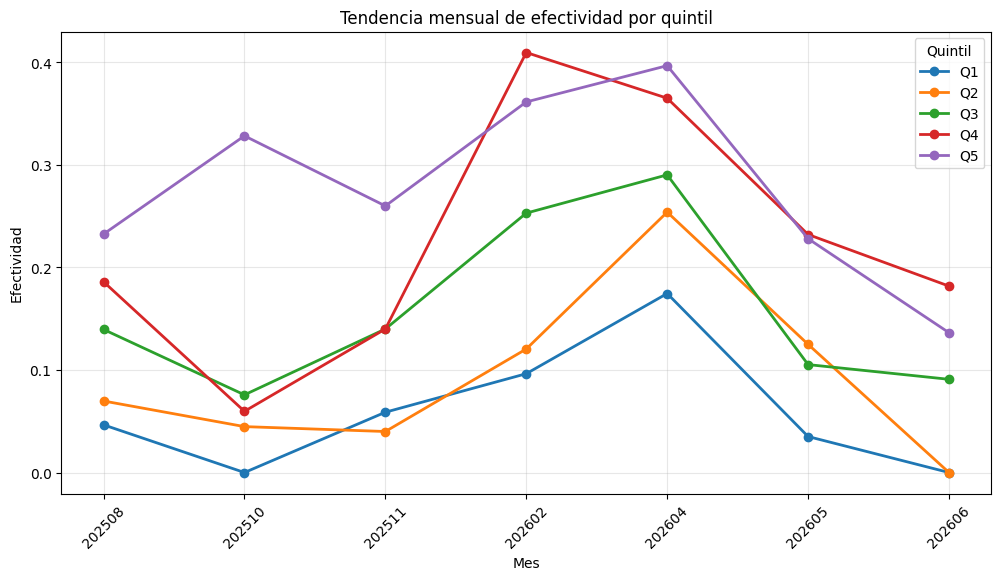

In [86]:
import matplotlib.pyplot as plt

pivot = df_quintiles.pivot_table(
    index="mes",
    columns="Quintil",
    values="Efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad por quintil")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

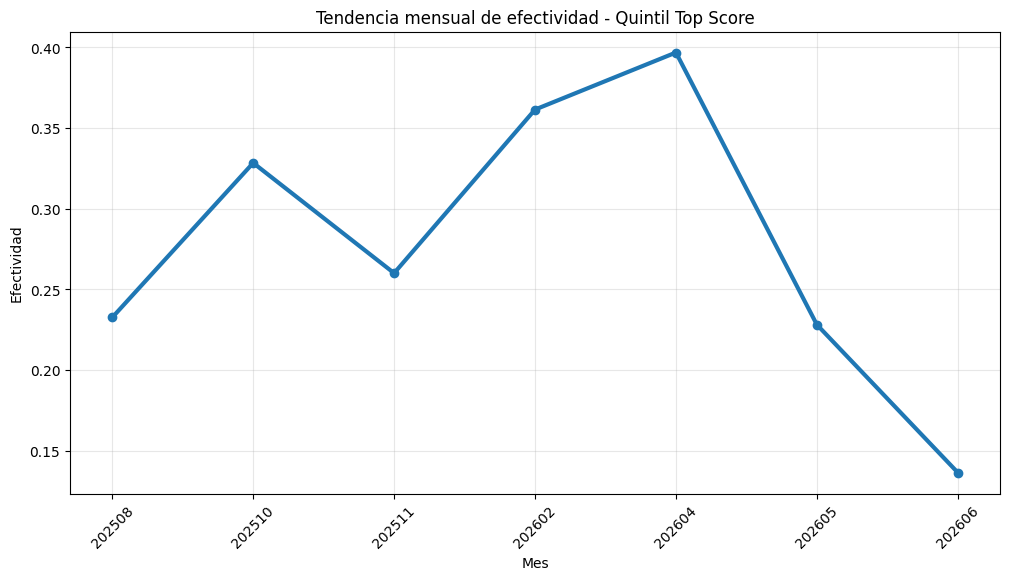

In [87]:
q_top = df_quintiles[df_quintiles["Quintil"] == 5].copy()

plt.figure(figsize=(12,6))

plt.plot(
    q_top["mes"],
    q_top["Efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - Quintil Top Score")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [88]:
# Meses a excluir
meses_excluir = ["202509", "202512","202601","202603"]

# Dataset para análisis
df_analisis = df_5[
    ~df_5["cod_mes"].astype(str).isin(meses_excluir)
].copy()

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. Mes base para cortes
# ================================
mes_base = "202508"

df_analisis["cod_mes"] = df_analisis["cod_mes"].astype(str)
df_analisis["prob"] = pd.to_numeric(df_analisis["prob"], errors="coerce")
df_analisis["target_m"] = pd.to_numeric(df_analisis["target_m"], errors="coerce")

base = df_analisis[df_analisis["cod_mes"] == mes_base].copy()

# Cortes fijos según 202508
cuts = base["prob"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).values

# Evitar problemas si hay cortes repetidos
cuts[0] = -float("inf")
cuts[-1] = float("inf")

print("Cortes base 202508:")
print(cuts)

Cortes base 202508:
[      -inf 0.22177999 0.63117152 0.85452255 0.95391023        inf]


In [ ]:


# ================================
# 2. Aplicar cortes fijos a todos los meses
# ================================
df_5["quintil_202508"] = pd.cut(
    df_5["prob"],
    bins=cuts,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# Q5 = mayor score
df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)

C:\Users\b46637\AppData\Local\Temp\ipykernel_50048\3537661944.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = pd.cut(
C:\Users\b46637\AppData\Local\Temp\ipykernel_50048\3537661944.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)


In [ ]:
df_analisis=df_5

In [ ]:
# ================================
# 3. Resumen por mes y quintil
# ================================
resumen_q = (
    df_analisis
    .groupby(["cod_mes", "quintil_202508"])
    .agg(
        cantidad=("target_m", "size"),
        casos_riesgo=("target_m", "sum"),
        efectividad=("target_m", "mean"),
        prob_min=("prob", "min"),
        prob_max=("prob", "max")
    )
    .reset_index()
)

display(resumen_q)

KeyError: 'quintil_202508'

In [ ]:
# ================================
# 4. Gráfico tendencia mensual
# ================================
pivot = resumen_q.pivot_table(
    index="cod_mes",
    columns="quintil_202508",
    values="efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad con cortes fijos de 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

NameError: name 'resumen_q' is not defined

In [ ]:
q5 = resumen_q[resumen_q["quintil_202508"] == 5]

plt.figure(figsize=(12,6))

plt.plot(
    q5["cod_mes"],
    q5["efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - Q5 con cortes 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

NameError: name 'resumen_q' is not defined

In [ ]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="left",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(24358542, 11)


,key_value,cuc_num,prob,cod_mes,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228,0.021226,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426,0.021720,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602,0.013532,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200,0.020246,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077,0.122736,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>


In [ ]:
df_merge.cod_mes.value_counts()

cod_mes
202605    8402197
202604    2085582
202602    2077945
202603    2048679
202601    1686260
202512    1654359
202511    1622987
202510    1609499
202508    1597744
202509    1573290
Name: count, dtype: int64

In [ ]:
# ================================================================
# Eliminar casos duplicados en df_merge
# ================================================================
candidate_keys = [
    ["key_value", "cod_mes"],
    ["key_value", "cuc_num", "cod_mes"],
    ["cuc_num", "cod_mes"],
    ["codunico", "codmes"],
]

dedup_keys = next((k for k in candidate_keys if all(col in df_merge.columns for col in k)), None)
if dedup_keys is None:
    raise ValueError("No se encontró una combinación de llaves válida para deduplicar df_merge")

before_rows = len(df_merge)

# Priorizamos conservar el registro con mayor señal de riesgo
priority_cols = [c for c in ["target_m", "prob"] if c in df_merge.columns]
if priority_cols:
    df_merge = df_merge.sort_values(priority_cols, ascending=False)

duplicates_count = df_merge.duplicated(subset=dedup_keys, keep="first").sum()
df_merge = df_merge.drop_duplicates(subset=dedup_keys, keep="first").reset_index(drop=True)
after_rows = len(df_merge)

print(f"Llaves usadas para deduplicar: {dedup_keys}")
print(f"Filas antes: {before_rows:,}")
print(f"Duplicados eliminados: {duplicates_count:,}")
print(f"Filas después: {after_rows:,}")

# Verificación por mes
df_merge.cod_mes.value_counts()

Llaves usadas para deduplicar: ['key_value', 'cod_mes']
Filas antes: 24,358,542
Duplicados eliminados: 2,082,746
Filas después: 22,275,796


cod_mes
202605    6319657
202604    2085558
202602    2077904
202603    2048661
202601    1686241
202512    1654353
202511    1622970
202510    1609433
202508    1597736
202509    1573283
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)

In [ ]:
meses = [202508, 202509, 202510, 202511, 202512, 202604, 202605]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    test_data_alerta = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if test_data_alerta.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target_m",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k
    print(f"✅ Mes {mes_str}: {len(test_data_alerta):,} registros")


✅ Mes 202508: 1,597,736 registros
✅ Mes 202509: 1,573,283 registros
✅ Mes 202509: 1,573,283 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202512: 1,654,353 registros
✅ Mes 202512: 1,654,353 registros
✅ Mes 202604: 2,085,558 registros
✅ Mes 202604: 2,085,558 registros
✅ Mes 202605: 6,319,657 registros
✅ Mes 202605: 6,319,657 registros


In [ ]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.976792,3,0.025424,0.0300,202508
1,200,0.971017,5,0.042373,0.0250,202508
2,500,0.958340,13,0.110169,0.0260,202508
3,1000,0.940208,19,0.161017,0.0190,202508
4,2000,0.911254,29,0.245763,0.0145,202508
5,100,0.980349,1,0.013889,0.0100,202509
6,200,0.972947,1,0.013889,0.0050,202509
7,500,0.959744,5,0.069444,0.0100,202509
8,1000,0.942344,8,0.111111,0.0080,202509
9,2000,0.914315,11,0.152778,0.0055,202509


In [ ]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [ ]:
resultados_mes = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    df_mes = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if df_mes.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target_m",  # columna correcta en df_merge
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla
    print(f"✅ Mes {mes_str}: {len(df_mes):,} registros")


✅ Mes 202508: 1,597,736 registros
✅ Mes 202509: 1,573,283 registros
✅ Mes 202509: 1,573,283 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202512: 1,654,353 registros
✅ Mes 202512: 1,654,353 registros
✅ Mes 202604: 2,085,558 registros
✅ Mes 202604: 2,085,558 registros
✅ Mes 202605: 6,319,657 registros
✅ Mes 202605: 6,319,657 registros


In [ ]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))


Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
3,4,800,0.94698,0.0225,0.152542,0.039216



Mes 202509


,grupo,casos_hasta,threshold,precision,recall,f1
1,2,400,0.963925,0.01,0.055556,0.016949



Mes 202510


...

,grupo,casos_hasta,threshold,precision,recall,f1
4,5,1000,0.94155,0.001,0.052632,0.001963



Mes 202604


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.958507,0.045,0.161677,0.070404



Mes 202605


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.990385,0.005,0.013636,0.007317


In [ ]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos

,grupo,casos_hasta,threshold,precision,recall,f1,mes
3,4.0,800.0,0.946980,0.0225,0.152542,0.039216,202508.0
1,2.0,400.0,0.963925,0.0100,0.055556,0.016949,202509.0
0,1.0,200.0,0.973181,0.0500,0.096154,0.065789,202510.0
3,4.0,800.0,0.947219,0.0150,0.187500,0.027778,202511.0
4,5.0,1000.0,0.941550,0.0010,0.052632,0.001963,202512.0
2,3.0,600.0,0.958507,0.0450,0.161677,0.070404,202604.0
2,3.0,600.0,0.990385,0.0050,0.013636,0.007317,202605.0


In [ ]:
# ================================================================
# Threshold final: percentil 75 de los thresholds óptimos por mes
# Cada mes aporta el score mínimo que maximizó F1 en ese mes.
# p75 → más restrictivo que el óptimo del 75% de los meses
#        → menos alertas, mayor precision
# ================================================================
threshold_final = df_optimos["threshold"].quantile(0.93)

print(f"Threshold final (p75): {threshold_final:.4f}\n")
print(f"Thresholds óptimos por mes (los que maximizan F1):")
display(df_optimos[["mes", "threshold", "precision", "recall", "f1"]])

print(f"\nImpacto del threshold {threshold_final:.4f} por mes:")
resumen_final = (
    df_merge[df_merge["prob"] >= threshold_final]
    .groupby("cod_mes")
    .agg(
        alertas=("prob", "count"),
        positivos=("target_m", "sum")
    )
    .assign(precision=lambda d: (d["positivos"] / d["alertas"]).round(3))
)
resumen_final.index = resumen_final.index.astype(str)
display(resumen_final)


Threshold final (p75): 0.9832

Thresholds óptimos por mes (los que maximizan F1):


,mes,threshold,precision,recall,f1
3,202508.0,0.946980,0.0225,0.152542,0.039216
1,202509.0,0.963925,0.0100,0.055556,0.016949
0,202510.0,0.973181,0.0500,0.096154,0.065789
3,202511.0,0.947219,0.0150,0.187500,0.027778
4,202512.0,0.941550,0.0010,0.052632,0.001963
2,202604.0,0.958507,0.0450,0.161677,0.070404
2,202605.0,0.990385,0.0050,0.013636,0.007317



Impacto del threshold 0.9832 por mes:


,alertas,positivos,precision
cod_mes,,,
202508,49,3,0.061
202509,74,0,0.0
202510,57,2,0.035
202511,61,1,0.016
202512,68,0,0.0
202601,63,4,0.063
202602,82,5,0.061
202603,103,9,0.087
202604,84,4,0.048
